# Does a Free Curbside Composting Program Actually Reduce Landfill Waste?
### A hands-on causal inference project based on *Causal Inference in Python* (Matheus Facure), Chapter 1

**The policy question:** You work for a city's Department of Sanitation. To
cut landfill volume (and the fees the city pays per ton at the landfill), the
department started offering **free curbside composting bins** to households
that sign up. Enrollment is **voluntary** — households opt in themselves.

After a year, the department wants to know: *does composting-bin enrollment
(`has_compost_bin`) actually cause a reduction in `weekly_landfill_kg`*, so
the city can decide whether to fund a full rollout (mandatory bins, city-wide
budget) versus keep it opt-in.

This notebook rebuilds the book's Chapter 1 toolkit — potential outcomes,
ATE/ATT/CATE, the bias equation, and randomization — but applied end-to-end
to a **waste management** setting instead of the book's marketplace-sales
example. We will:

1. Simulate a realistic **observational** dataset where more
   environmentally-engaged households are both more likely to sign up for
   composting *and* already generate less landfill waste to begin with (a
   confounder).
2. Show how a naive comparison of means gives a **biased** answer — and
   prove it, because in simulation we can peek at ground-truth potential
   outcomes.
3. Formalize the problem with **potential outcomes notation** ($Y_0$, $Y_1$)
   and compute **ATE**, **ATT**, and **CATE** exactly.
4. Derive and verify the **bias equation**:
   $$E[Y|T=1]-E[Y|T=0] = \underbrace{E[Y_1-Y_0|T=1]}_{ATT} + \underbrace{\{E[Y_0|T=1]-E[Y_0|T=0]\}}_{Bias}$$
5. Visualize the confounding, Simpson's-Paradox-style.
6. Simulate a **randomized rollout** (bins mailed to a random half of
   households, whether they asked or not) and show that randomization makes
   the naive comparison **unbiased**.
7. Wrap up with a short **checklist** you can reuse on any real
   sanitation/policy causal question.

> As before, we simulate the data ourselves (with a known, controllable
> amount of bias) so we can compare our *estimates* against the *true* causal
> effect — a luxury real municipal data never gives you. The point is to
> build intuition before applying these ideas to messy real-world sanitation
> data (weigh-tickets, route logs, census tract demographics, etc.).


## Step 0 — Setup


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
rng = np.random.default_rng(42)  # reproducibility

pd.set_option("display.precision", 2)


## Step 1 — Simulate the world (with god-like powers)

The fundamental problem of causal inference: for any real household, you
only ever observe **one** potential outcome — landfill waste **with** a
compost bin ($Y_1$) or **without** one ($Y_0$), never both. Since this is a
simulation, we get to generate **both** potential outcomes for every
household, so we can check our estimates against ground truth later.

**The data-generating process we'll encode:**

- `env_engagement`: a 0-100 score capturing how environmentally engaged a
  household already is (recycles consistently, buys less packaging, etc.).
  This is the **confounder** — it drives both whether a household signs up
  for composting *and* how much landfill waste it produces regardless.
- `household_size`: number of people in the household (1 to 6) — a second
  covariate, used later for CATE.
- `Y0` (`landfill_kg_0`): potential weekly landfill waste **without** a
  compost bin. More engaged households already throw away less.
- `Y1` (`landfill_kg_1`): potential weekly landfill waste **with** a compost
  bin. The bin has a real, negative effect (diverts food/yard waste out of
  the landfill stream), and that effect is larger for bigger households
  (more food waste to divert in the first place).
- `has_compost_bin` (T): **more environmentally engaged households are more
  likely to sign up.** This is what creates the confounding bias — signup is
  *not* random.


In [2]:
n_households = 2000

# --- Confounder: environmental engagement score (0-100) ---
env_engagement = np.clip(rng.normal(50, 20, size=n_households), 0, 100)

# --- Second covariate used later for CATE ---
household_size = rng.integers(1, 7, size=n_households)  # 1..6 people

# --- True individual treatment effect ---
# Base effect of a compost bin: reduces landfill waste by ~3 kg/week,
# with a bigger reduction for larger households (more compostable waste to divert),
# plus individual random variation (some households use the bin more diligently than others).
base_effect = -3.0
size_boost = -0.8 * (household_size - 1)   # each extra person -> 0.8 kg/week more reduction
individual_noise = rng.normal(0, 1.2, size=n_households)

true_ite = base_effect + size_boost + individual_noise   # individual treatment effect, tau_i

# --- Potential outcomes ---
noise0 = rng.normal(0, 1.5, size=n_households)
# More engaged households + bigger households already generate different baseline waste:
Y0 = 18 - 0.09 * env_engagement + 1.2 * household_size + noise0   # landfill kg/week WITHOUT bin
Y1 = Y0 + true_ite                                                 # landfill kg/week WITH bin
Y0 = np.clip(Y0, 0.5, None)
Y1 = np.clip(Y1, 0.5, None)

# --- Treatment assignment: NOT random. More engaged households more likely to sign up. ---
# This is the confounding mechanism: env_engagement -> has_compost_bin AND env_engagement -> Y0
propensity_logit = -3 + 0.07 * env_engagement
propensity = 1 / (1 + np.exp(-propensity_logit))
has_compost_bin = rng.binomial(1, propensity)

# --- What we would ACTUALLY observe in the real world (only one potential outcome) ---
landfill_kg = np.where(has_compost_bin == 1, Y1, Y0)

df = pd.DataFrame({
    "household_id": np.arange(n_households),
    "env_engagement": env_engagement,
    "household_size": household_size,
    "has_compost_bin": has_compost_bin,
    "weekly_landfill_kg": landfill_kg,   # <- this is all you'd see in real data
    "Y0_true": Y0,                       # <- god-mode only: true potential outcome, no bin
    "Y1_true": Y1,                       # <- god-mode only: true potential outcome, with bin
    "true_ite": true_ite,                # <- god-mode only: true individual effect
})

print(f"{df['has_compost_bin'].mean():.1%} of households signed up for a compost bin.")
df.head(10)


54.8% of households signed up for a compost bin.


,household_id,env_engagement,household_size,has_compost_bin,weekly_landfill_kg,Y0_true,Y1_true,true_ite
0,0,56.09,5,0,18.02,18.02,10.21,-7.81
1,1,29.20,1,0,16.79,16.79,12.85,-3.94
2,2,65.01,3,1,11.84,16.59,11.84,-4.75
3,3,68.81,3,1,11.77,17.10,11.77,-5.33
4,4,10.98,6,0,23.14,23.14,18.90,-4.24
5,5,23.96,4,1,16.02,21.52,16.02,-5.51
6,6,52.56,4,1,14.82,18.36,14.82,-3.55
7,7,43.68,1,1,9.47,12.70,9.47,-3.23
8,8,49.66,5,1,16.49,22.38,16.49,-5.89
9,9,32.94,3,0,16.48,16.48,10.29,-6.19


## Step 2 — What a real analyst would see

In the real world you would **never** have `Y0_true`, `Y1_true`, or
`true_ite` — only `weekly_landfill_kg`, `has_compost_bin`, `env_engagement`
(maybe proxied by past recycling-participation records), and
`household_size`. Let's set aside the god-mode columns and look at what a
sanitation-department analyst actually has to work with.


In [3]:
observed = df[["household_id", "env_engagement", "household_size",
               "has_compost_bin", "weekly_landfill_kg"]].copy()
observed.head(10)


,household_id,env_engagement,household_size,has_compost_bin,weekly_landfill_kg
0,0,56.09,5,0,18.02
1,1,29.20,1,0,16.79
2,2,65.01,3,1,11.84
3,3,68.81,3,1,11.77
4,4,10.98,6,0,23.14
5,5,23.96,4,1,16.02
6,6,52.56,4,1,14.82
7,7,43.68,1,1,9.47
8,8,49.66,5,1,16.49
9,9,32.94,3,0,16.48


## Step 3 — The naive (and wrong) approach: just compare the means

The analysis most people reach for first: average `weekly_landfill_kg` for
households with a bin, minus the average for households without one. In
potential-outcome notation this is the **association**:

$$E[Y\,|\,T=1] - E[Y\,|\,T=0]$$


In [4]:
naive_diff = observed.loc[observed.has_compost_bin == 1, "weekly_landfill_kg"].mean() - \
             observed.loc[observed.has_compost_bin == 0, "weekly_landfill_kg"].mean()

print(f"Naive association  E[Y|T=1] - E[Y|T=0]  =  {naive_diff:.2f} kg/week")


Naive association  E[Y|T=1] - E[Y|T=0]  =  -6.86 kg/week


Because we have god-mode access, we can check this against the **true**
average treatment effect, $ATE = E[Y_1 - Y_0]$, computed for every single
household:


In [5]:
true_ate = (df["Y1_true"] - df["Y0_true"]).mean()
true_att = (df.loc[df.has_compost_bin == 1, "Y1_true"] - df.loc[df.has_compost_bin == 1, "Y0_true"]).mean()

print(f"TRUE ATE   (E[Y1 - Y0])              = {true_ate:.2f} kg/week")
print(f"TRUE ATT   (E[Y1 - Y0 | T=1])         = {true_att:.2f} kg/week")
print(f"Naive association  E[Y|T=1]-E[Y|T=0]  = {naive_diff:.2f} kg/week")
print(f"\nDiscrepancy vs. true ATE: {naive_diff - true_ate:+.2f} kg/week "
      f"({(naive_diff/true_ate - 1):+.1%})")


TRUE ATE   (E[Y1 - Y0])              = -4.99 kg/week
TRUE ATT   (E[Y1 - Y0 | T=1])         = -4.96 kg/week
Naive association  E[Y|T=1]-E[Y|T=0]  = -6.86 kg/week

Discrepancy vs. true ATE: -1.87 kg/week (+37.4%)


Just like in the book's sales example, the naive comparison is **biased** —
but here it's biased in the *flattering* direction: the naive number is
*more negative* than the true ATE, meaning the program looks like it saves
more landfill waste than it actually does. That's because households that
signed up were already more environmentally engaged and would have thrown
away less landfill waste *regardless* of the bin — the naive comparison
mixes "the effect of the bin" together with "the effect of already being an
engaged household," and the two get credited entirely to the bin.


## Step 4 — Prove it with the bias equation

$$
\underbrace{E[Y|T=1]-E[Y|T=0]}_{\text{association}}
\;=\;
\underbrace{E[Y_1-Y_0\,|\,T=1]}_{ATT}
\;+\;
\underbrace{\{E[Y_0|T=1] - E[Y_0|T=0]\}}_{\text{Bias}}
$$

Let's compute every term directly from our god-mode data and confirm the
identity holds, then see how large the bias term is.


In [6]:
E_Y0_given_T1 = df.loc[df.has_compost_bin == 1, "Y0_true"].mean()
E_Y0_given_T0 = df.loc[df.has_compost_bin == 0, "Y0_true"].mean()
bias = E_Y0_given_T1 - E_Y0_given_T0

print(f"E[Y0 | T=1]  (what bin households would've thrown away WITHOUT the bin) = {E_Y0_given_T1:.2f}")
print(f"E[Y0 | T=0]  (what non-bin households actually threw away, no bin)      = {E_Y0_given_T0:.2f}")
print(f"BIAS = E[Y0|T=1] - E[Y0|T=0]                                            = {bias:.2f}")
print()
print(f"ATT + Bias = {true_att:.2f} + {bias:.2f} = {true_att + bias:.2f}")
print(f"Naive association (measured directly)                                   = {naive_diff:.2f}")
print("\n--> The identity holds (up to simulation noise). The bias comes entirely")
print("    from env_engagement being a common cause of both signup and baseline waste.")


E[Y0 | T=1]  (what bin households would've thrown away WITHOUT the bin) = 16.96
E[Y0 | T=0]  (what non-bin households actually threw away, no bin)      = 18.86
BIAS = E[Y0|T=1] - E[Y0|T=0]                                            = -1.90

ATT + Bias = -4.96 + -1.90 = -6.86
Naive association (measured directly)                                   = -6.86

--> The identity holds (up to simulation noise). The bias comes entirely
    from env_engagement being a common cause of both signup and baseline waste.


## Step 5 — Visualize the confounding

### 5a. Outcome by treatment
A boxplot alone hides the confounder entirely — it just contrasts two groups
that were never comparable to begin with.


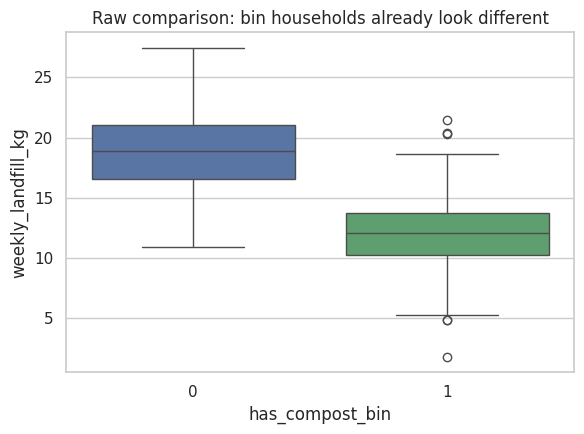

In [7]:
fig, ax = plt.subplots(figsize=(6, 4.5))
sns.boxplot(data=observed, x="has_compost_bin", y="weekly_landfill_kg", ax=ax,
            hue="has_compost_bin", palette={0: "#4C72B0", 1: "#55A868"}, legend=False)
ax.set_xlabel("has_compost_bin")
ax.set_ylabel("weekly_landfill_kg")
ax.set_title("Raw comparison: bin households already look different")
plt.tight_layout()
plt.show()


### 5b. Outcome vs. the confounder, colored by treatment

Now let's bring `env_engagement` into the picture. If bin (green) and no-bin
(blue) households cluster in different regions of `env_engagement`, that's a
visual signature of confounding — the two groups are **not exchangeable**.


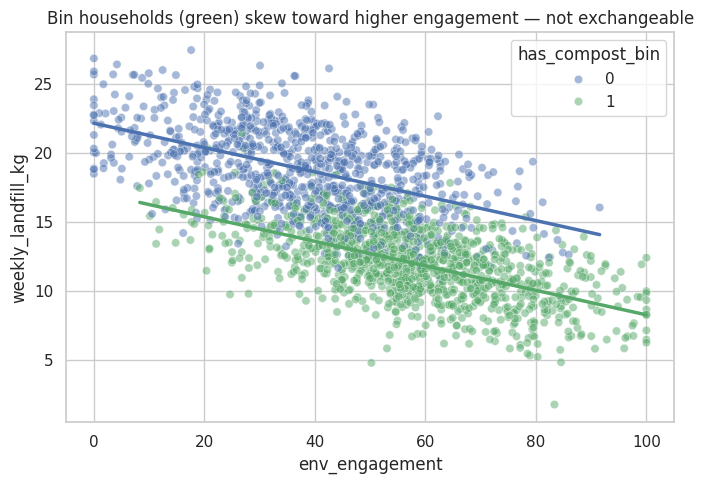

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(
    data=observed, x="env_engagement", y="weekly_landfill_kg",
    hue="has_compost_bin", palette={0: "#4C72B0", 1: "#55A868"},
    alpha=0.5, ax=ax
)
for t, color in [(0, "#4C72B0"), (1, "#55A868")]:
    sub = observed[observed.has_compost_bin == t]
    z = np.polyfit(sub.env_engagement, sub.weekly_landfill_kg, 1)
    xs = np.linspace(sub.env_engagement.min(), sub.env_engagement.max(), 50)
    ax.plot(xs, np.polyval(z, xs), color=color, linewidth=2.5)

ax.set_title("Bin households (green) skew toward higher engagement — not exchangeable")
ax.legend(title="has_compost_bin")
plt.tight_layout()
plt.show()


### 5c. Simpson's-Paradox-style check: does the effect survive within engagement bins?

Zooming into households of similar engagement should shrink — but not flip —
the apparent effect of the bin, if this is "regular" confounding rather than
a full paradox. Let's bin households by `env_engagement` and compare bin vs.
no-bin **within each bin**.


In [9]:
observed_binned = observed.copy()
observed_binned["engagement_bin"] = pd.qcut(observed_binned["env_engagement"], q=5,
                                             labels=["Low", "Low-Mid", "Mid", "Mid-High", "High"])

within_bin = (
    observed_binned
    .groupby(["engagement_bin", "has_compost_bin"], observed=True)["weekly_landfill_kg"]
    .mean()
    .unstack("has_compost_bin")
)
within_bin.columns = ["mean_landfill_kg_no_bin", "mean_landfill_kg_with_bin"]
within_bin["within_bin_diff"] = (
    within_bin["mean_landfill_kg_with_bin"] - within_bin["mean_landfill_kg_no_bin"]
)
within_bin


,mean_landfill_kg_no_bin,mean_landfill_kg_with_bin,within_bin_diff
engagement_bin,,,
Low,20.48,14.92,-5.56
Low-Mid,18.72,13.69,-5.03
Mid,17.68,12.96,-4.72
Mid-High,17.18,11.78,-5.40
High,15.89,10.31,-5.58


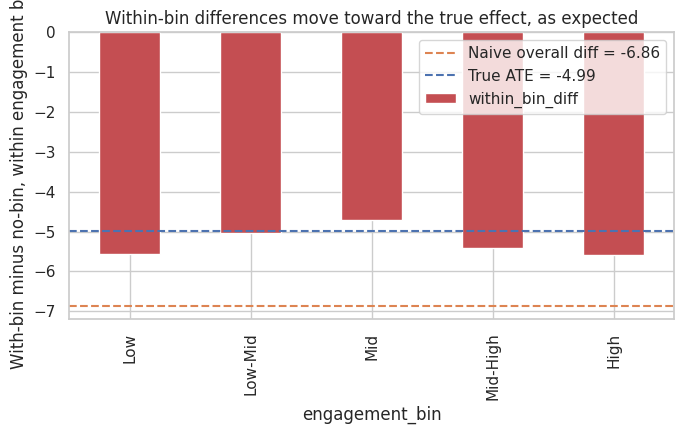

In [10]:
fig, ax = plt.subplots(figsize=(7, 4.5))
within_bin["within_bin_diff"].plot(kind="bar", ax=ax, color="#C44E52")
ax.axhline(naive_diff, color="#DD8452", linestyle="--",
           label=f"Naive overall diff = {naive_diff:.2f}")
ax.axhline(true_ate, color="#4C72B0", linestyle="--",
           label=f"True ATE = {true_ate:.2f}")
ax.set_ylabel("With-bin minus no-bin, within engagement bin")
ax.set_title("Within-bin differences move toward the true effect, as expected")
ax.legend()
plt.tight_layout()
plt.show()


Notice how the within-bin differences sit **much closer to the true ATE**
than the naive overall difference — the same mechanism the book illustrates
with its Figure 1-3: controlling for the confounder (`env_engagement`)
corrects the biased association, without flipping its sign.


## Step 6 — Compute ATE, ATT, and CATE (god-mode, for validation)

- $ATE = E[Y_1 - Y_0]$
- $ATT = E[Y_1 - Y_0 \mid T=1]$
- $CATE(x) = E[Y_1 - Y_0 \mid X=x]$

We already computed ATE and ATT above. Let's now compute **CATE by
`household_size`**, matching the idea baked into our simulation that
composting saves more landfill waste for larger households.


In [11]:
df["ite"] = df["Y1_true"] - df["Y0_true"]

cate_by_size = df.groupby("household_size")["ite"].mean().rename("CATE").to_frame()
cate_by_size["n_households"] = df.groupby("household_size").size()
cate_by_size


,CATE,n_households
household_size,,
1,-2.96,333
2,-3.82,349
3,-4.65,331
4,-5.40,334
5,-6.16,327
6,-7.06,326


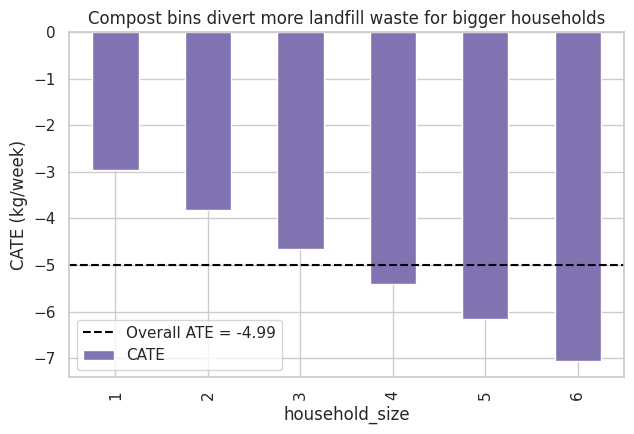

In [12]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
cate_by_size["CATE"].plot(kind="bar", ax=ax, color="#8172B2")
ax.axhline(true_ate, color="black", linestyle="--", label=f"Overall ATE = {true_ate:.2f}")
ax.set_xlabel("household_size")
ax.set_ylabel("CATE (kg/week)")
ax.set_title("Compost bins divert more landfill waste for bigger households")
ax.legend()
plt.tight_layout()
plt.show()


**Policy takeaway:** if you could only recover this pattern from real data
(no god-mode), you'd tell the department to **prioritize outreach to larger
households** when expanding the program — this is the "targeting" use case
for CATE the book highlights, applied to municipal resource allocation
instead of marketing.


## Step 7 — Fix it: what if bin assignment were randomized?

Identification requires knowing (or assuming) something about *how the
treatment was assigned*. The cleanest assumption is **randomization**, which
forces the independence assumption $(Y_0, Y_1) \perp T$ to hold by
construction.

Let's simulate the **randomized-rollout version** of this program: instead of
opt-in signup, the department mails a compost bin to a **random** half of
households (a real design municipalities sometimes use for pilot programs).
Everything else about the data-generating process — including each
household's *true* potential outcomes `Y0_true`/`Y1_true` — stays exactly the
same. Only the assignment mechanism changes.


In [13]:
# Same households, same true potential outcomes, but NOW assignment is a coin flip,
# independent of env_engagement.
rct_has_bin = rng.binomial(1, 0.5, size=n_households)
rct_landfill_kg = np.where(rct_has_bin == 1, df["Y1_true"], df["Y0_true"])

rct = pd.DataFrame({
    "env_engagement": df["env_engagement"],
    "household_size": df["household_size"],
    "has_compost_bin": rct_has_bin,
    "weekly_landfill_kg": rct_landfill_kg,
})

rct_diff = rct.loc[rct.has_compost_bin == 1, "weekly_landfill_kg"].mean() - \
           rct.loc[rct.has_compost_bin == 0, "weekly_landfill_kg"].mean()

print(f"TRUE ATE                                    = {true_ate:.2f}")
print(f"Naive diff on OBSERVATIONAL (biased) data   = {naive_diff:.2f}   <-- distorted by self-selection")
print(f"Naive diff on RANDOMIZED data               = {rct_diff:.2f}   <-- recovers the true ATE")


TRUE ATE                                    = -4.99
Naive diff on OBSERVATIONAL (biased) data   = -6.86   <-- distorted by self-selection
Naive diff on RANDOMIZED data               = -5.02   <-- recovers the true ATE


Under randomization, the simple difference in means is now an **unbiased**
estimator of the ATE — matching the book's claim that
$E[Y|T=1]-E[Y|T=0] = ATT = ATE = E[Y_1-Y_0]$ once treated and control groups
are made exchangeable.

Let's confirm visually that the confounding has vanished: `env_engagement`
should now be **balanced** between bin and no-bin households.


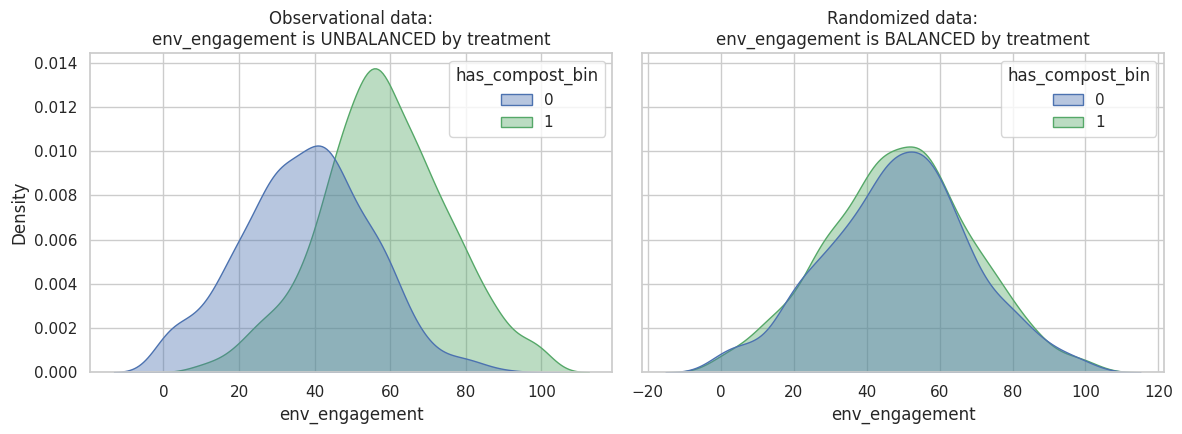

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

sns.kdeplot(data=observed, x="env_engagement", hue="has_compost_bin",
            palette={0: "#4C72B0", 1: "#55A868"}, ax=axes[0], fill=True, alpha=0.4)
axes[0].set_title("Observational data:\nenv_engagement is UNBALANCED by treatment")

sns.kdeplot(data=rct, x="env_engagement", hue="has_compost_bin",
            palette={0: "#4C72B0", 1: "#55A868"}, ax=axes[1], fill=True, alpha=0.4)
axes[1].set_title("Randomized data:\nenv_engagement is BALANCED by treatment")

plt.tight_layout()
plt.show()


## Step 8 — Sanity checks on the book's key assumptions

Before trusting any causal estimate, check (or assume):

1. **Consistency** — the observed outcome equals the potential outcome under
   the treatment actually received: $Y_i = T_i Y_{1i} + (1-T_i) Y_{0i}$.
2. **SUTVA / no interference** — one household's bin doesn't affect a
   *different* household's landfill weight.
3. **Independence** ($(Y_0,Y_1) \perp T$) — needed for the naive comparison
   to equal the ATE.

Let's verify #1 numerically (true by construction here, but exactly the kind
of check you'd script for a real dataset), and discuss #2 and #3.


In [15]:
# 1. Consistency check
reconstructed = np.where(df["has_compost_bin"] == 1, df["Y1_true"], df["Y0_true"])
consistency_holds = np.allclose(reconstructed, df["weekly_landfill_kg"])
print(f"Consistency assumption holds: {consistency_holds}")

# 3. Independence check (only verifiable here because of god-mode access!)
print(f"\nIndependence check, OBSERVATIONAL data:")
print(f"  E[Y0 | T=1] = {df.loc[df.has_compost_bin==1,'Y0_true'].mean():.2f}")
print(f"  E[Y0 | T=0] = {df.loc[df.has_compost_bin==0,'Y0_true'].mean():.2f}   <- clearly different: independence VIOLATED")

print(f"\nIndependence check, RANDOMIZED data:")
rct_Y0 = df["Y0_true"]  # same underlying potential outcomes, just re-labeled by rct assignment
print(f"  E[Y0 | T=1] = {rct_Y0[rct_has_bin==1].mean():.2f}")
print(f"  E[Y0 | T=0] = {rct_Y0[rct_has_bin==0].mean():.2f}   <- nearly identical: independence holds (up to sampling noise)")


Consistency assumption holds: True

Independence check, OBSERVATIONAL data:
  E[Y0 | T=1] = 16.96
  E[Y0 | T=0] = 18.86   <- clearly different: independence VIOLATED

Independence check, RANDOMIZED data:
  E[Y0 | T=1] = 17.80
  E[Y0 | T=0] = 17.84   <- nearly identical: independence holds (up to sampling noise)


**SUTVA** is a judgment call, not something we can check numerically here: we
assumed one household's compost bin doesn't change a *different* household's
landfill weight. This is plausible for most residential composting (waste
generation is a household-level decision), but could be **violated** if
neighbors share a bin, or if a mandatory-bin rollout changes collection-route
frequency or truck capacity city-wide (a "general equilibrium" effect) — a
real risk worth flagging before scaling a pilot to the whole city.


## Step 9 — Summary table: every causal quantity, side by side


In [16]:
summary = pd.DataFrame({
    "Quantity": [
        "True ATE  (god-mode)",
        "True ATT  (god-mode)",
        "Naive association — OBSERVATIONAL (opt-in) data",
        "Naive association — RANDOMIZED rollout data",
        "Bias term  (E[Y0|T=1] - E[Y0|T=0])",
    ],
    "Value (kg/week)": [
        true_ate,
        true_att,
        naive_diff,
        rct_diff,
        bias,
    ]
}).round(2)
summary


,Quantity,Value (kg/week)
0,True ATE (god-mode),-4.99
1,True ATT (god-mode),-4.96
2,Naive association — OBSERVATIONAL (opt-in) data,-6.86
3,Naive association — RANDOMIZED rollout data,-5.02
4,Bias term (E[Y0|T=1] - E[Y0|T=0]),-1.90


## Key takeaways / reusable checklist

1. **Never trust a raw difference in means** (association) as the effect of
   a sanitation program until you've thought hard about how households
   ended up treated vs. untreated.
2. Formalize the question with **potential outcomes** ($Y_0$, $Y_1$) — this
   forces you to be explicit about the *counterfactual* you're actually
   after ("what would this household have thrown away without the bin?").
3. Use the **bias equation** to reason about *why* a naive estimate might be
   off, and in *which direction* — here, "environmentally engaged households
   self-select into the program" distorts the naive estimate.
4. Whenever possible, **randomize** the treatment (e.g., mail bins to a
   random subset for a pilot). It's the only mechanism that ties $T$ to a
   coin flip and forces $(Y_0,Y_1)\perp T$, making the naive comparison
   unbiased.
5. When you can't randomize (most real municipal rollouts are opt-in or
   phased by neighborhood), you'll need tools from later chapters —
   regression adjustment, matching, propensity scores, instrumental
   variables, diff-in-diff — precisely *because* you have to substitute for
   randomization using assumptions about the data-generating process.
6. Always state your assumptions explicitly: **consistency**, **SUTVA**, and
   **independence** (or a substitute for it) are beliefs about the world
   that data alone cannot verify — and for city-scale rollouts, SUTVA in
   particular deserves real scrutiny (truck routes, collection frequency,
   shared bins).

### Where to go next
This notebook stayed inside Chapter 1's toolkit (potential outcomes, ATE/ATT/
CATE, bias, randomization) applied to waste management. A natural follow-up
project is to **re-run Step 3-4 on the *observational* (opt-in) dataset using
regression adjustment or propensity-score matching** to try to recover the
true ATE without a randomized pilot, and see how close you can get — directly
useful if your city already has a year of opt-in enrollment data and can't
afford to wait for a randomized trial.
